# Setting up the environment
Mount drive, install packages.

In [13]:
# Install dependencies
!pip install -q transformers torch sentencepiece
import os
import json

# Mount drive
from google.colab import drive
drive.mount('/content/drive')
PROJECT_DIR = '/content/drive/MyDrive/lecture-summarizer'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading the arxiv abstract-article database

In [14]:
# Install the datasets library if not already installed
!pip install -q datasets

from datasets import load_dataset

# Load arxiv-summarization
# This will download ~600MB the first time
print("Loading ccdv/arxiv-summarization...")
arxiv = load_dataset("ccdv/arxiv-summarization", trust_remote_code=True)

print(f"\nDataset structure: {arxiv}")
print(f"\nTrain size: {len(arxiv['train'])}")
print(f"Validation size: {len(arxiv['validation'])}")
print(f"Test size: {len(arxiv['test'])}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ccdv/arxiv-summarization' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ccdv/arxiv-summarization' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading ccdv/arxiv-summarization...

Dataset structure: DatasetDict({
    train: Dataset({
        features: ['article', 'abstract'],
        num_rows: 203037
    })
    validation: Dataset({
        features: ['article', 'abstract'],
        num_rows: 6436
    })
    test: Dataset({
        features: ['article', 'abstract'],
        num_rows: 6440
    })
})

Train size: 203037
Validation size: 6436
Test size: 6440


Quick inspection of sample to understand the training data from arxiv: abstract (article summary i.e., label) - article (i.e., input)

In [15]:
# Look at a sample
sample = arxiv['train'][0]
print("Available keys:", list(sample.keys()))
print(f"\n--- Article (first 500 chars) ---")
print(sample['article'][:500])
print(f"\n--- Abstract ---")
print(sample['abstract'])
print(f"\n--- Lengths ---")
print(f"Article: {len(sample['article'].split())} words")
print(f"Abstract: {len(sample['abstract'].split())} words")

Available keys: ['article', 'abstract']

--- Article (first 500 chars) ---
additive models @xcite provide an important family of models for semiparametric regression or classification . some reasons for the success of additive models are their increased flexibility when compared to linear or generalized linear models and their increased interpretability when compared to fully nonparametric models . 
 it is well - known that good estimators in additive models are in general less prone to the curse of high dimensionality than good estimators in fully nonparametric models

--- Abstract ---
additive models play an important role in semiparametric statistics . 
 this paper gives learning rates for regularized kernel based methods for additive models . 
 these learning rates compare favourably in particular in high dimensions to recent results on optimal learning rates for purely nonparametric regularized kernel based quantile regression using the gaussian radial basis function kernel , prov

Defining traning and validation datasets

In [16]:
# Take a random 5K subset of training data
# Use a seed for reproducibility
TRAIN_SIZE = 5000
VAL_SIZE = 500  # small validation set to check progress

train_subset = arxiv['train'].shuffle(seed=42).select(range(TRAIN_SIZE))
val_subset = arxiv['validation'].shuffle(seed=42).select(range(VAL_SIZE))

print(f"Training subset: {len(train_subset)} examples")
print(f"Validation subset: {len(val_subset)} examples")

# Quick stats
train_article_lens = [len(ex['article'].split()) for ex in train_subset.select(range(100))]
train_abstract_lens = [len(ex['abstract'].split()) for ex in train_subset.select(range(100))]

print(f"\nFirst 100 training samples (word counts):")
print(f"  Article:  median={sorted(train_article_lens)[50]}, max={max(train_article_lens)}, min={min(train_article_lens)}")
print(f"  Abstract: median={sorted(train_abstract_lens)[50]}, max={max(train_abstract_lens)}, min={min(train_abstract_lens)}")

Training subset: 5000 examples
Validation subset: 500 examples

First 100 training samples (word counts):
  Article:  median=4465, max=20703, min=330
  Abstract: median=190, max=4339, min=24


Filtering data to get rid of outliers. See 01_EDA.ipynb for further details on dataset characterization. We filter our edge cases where the summary is not aggressive enough (i.e. if the compression ratio > 30%)

In [17]:
import numpy as np

# Compute lengths and ratios BEFORE filtering, safely
before_article_lens = np.array([len(ex['article'].split()) for ex in train_subset])
before_abstract_lens = np.array([len(ex['abstract'].split()) for ex in train_subset])

# Diagnostic: count edge cases
n_zero_articles_before = (before_article_lens == 0).sum()
n_zero_abstracts_before = (before_abstract_lens == 0).sum()

# Compute ratios safely
with np.errstate(divide='ignore', invalid='ignore'):
    before_ratios_raw = before_abstract_lens / before_article_lens

valid_before_mask = np.isfinite(before_ratios_raw)
before_ratios = before_ratios_raw[valid_before_mask]
n_invalid_before = (~valid_before_mask).sum()

# Count how many BEFORE examples exceed compression thresholds
n_ratio_over_100 = (before_ratios > 1.0).sum()
n_ratio_over_80 = (before_ratios > 0.8).sum()
n_ratio_over_30 = (before_ratios > 0.3).sum()

# ---- FILTER (UPDATED to 30%) ----
COMPRESSION_RATIO_MAX = 0.3  # 30% — keeps only genuinely aggressive summaries

def filter_reasonable_length(example):
    article_words = len(example['article'].split())
    abstract_words = len(example['abstract'].split())
    if article_words < 200 or article_words > 15000:
        return False
    if abstract_words < 50 or abstract_words > 400:
        return False
    ratio = abstract_words / article_words
    if ratio > COMPRESSION_RATIO_MAX:
        return False
    return True

train_subset_filtered = train_subset.filter(filter_reasonable_length)
val_subset_filtered = val_subset.filter(filter_reasonable_length)

Tokenization





In [18]:
from transformers import T5Tokenizer

# Load T5 tokenizer (we likely already loaded the model earlier, but reload
# tokenizer fresh to be safe in case of state issues)
tokenizer = T5Tokenizer.from_pretrained("google-t5/t5-base")

# Configuration for tokenization
MAX_INPUT_LENGTH = 512      # T5-base's context window
MAX_TARGET_LENGTH = 512     # Target abstract length cap (most filtered abstracts < 200 words)
TASK_PREFIX = "summarize: "  # T5 needs this prefix to know what task to do

def preprocess_function(examples):
    """
    Convert (article, abstract) pairs into tokenized model inputs.

    Inputs get the 'summarize: ' prefix and are truncated to 512 tokens.
    Targets (the abstracts) are tokenized separately for the decoder.
    """
    # Add task prefix to articles
    inputs = [TASK_PREFIX + article for article in examples["article"]]

    # Tokenize inputs (encoder side)
    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False,  # we'll dynamically pad in the data collator
    )

    # Tokenize targets (decoder side / labels)
    labels = tokenizer(
        text_target=examples["abstract"],  # text_target tells T5 these are decoder targets
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding=False,
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# Apply tokenization to both train and validation sets
print("Tokenizing training set...")
tokenized_train = train_subset_filtered.map(
    preprocess_function,
    batched=True,
    remove_columns=train_subset_filtered.column_names,  # drop original 'article'/'abstract' columns
    desc="Tokenizing train",
)

print("\nTokenizing validation set...")
tokenized_val = val_subset_filtered.map(
    preprocess_function,
    batched=True,
    remove_columns=val_subset_filtered.column_names,
    desc="Tokenizing val",
)

# Sanity checks
print(f"\nTokenized train: {len(tokenized_train)} examples")
print(f"Tokenized val:   {len(tokenized_val)} examples")
print(f"\nFirst training example structure:")
sample = tokenized_train[0]
print(f"  input_ids:      length {len(sample['input_ids'])} (max {MAX_INPUT_LENGTH})")
print(f"  attention_mask: length {len(sample['attention_mask'])}")
print(f"  labels:         length {len(sample['labels'])} (max {MAX_TARGET_LENGTH})")
print(f"\nFirst input (decoded): {tokenizer.decode(sample['input_ids'][:100])}...")
print(f"First label (decoded): {tokenizer.decode(sample['labels'])}")

Tokenizing training set...

Tokenizing validation set...


Tokenizing val:   0%|          | 0/479 [00:00<?, ? examples/s]


Tokenized train: 4354 examples
Tokenized val:   479 examples

First training example structure:
  input_ids:      length 512 (max 512)
  attention_mask: length 512
  labels:         length 336 (max 512)

First input (decoded): summarize: arp 220 is the nearest ( @xmath3 77 mpc ) example of an ultraluminous infrared galaxy ( ulirg ) that supports star formation at extreme levels . it contains two nuclei separated by 350 pc , both surrounded by massive discs of dense molecular gas ( e.g. , * ? ? ? * ; * ? ? ...
First label (decoded): the cores of arp 220 , the closest ultraluminous infrared starburst galaxy , provide an opportunity to study interactions of cosmic rays under extreme conditions . in this paper , we model the populations of cosmic rays produced by supernovae in the central molecular zones of both starburst nuclei . we find that @xmath0 of cosmic rays are absorbed in these regions due to their huge molecular gas contents , and thus , the nuclei of arp 220 nearly complete pr

# Training T5 base model

Configuring the trainer

In [19]:
from transformers import (
    T5ForConditionalGeneration,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)

model = T5ForConditionalGeneration.from_pretrained("google-t5/t5-base")

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    return_tensors="pt",
)

training_args = Seq2SeqTrainingArguments(
    output_dir=f"{PROJECT_DIR}/models/t5_finetuned_v2_checkpoints",  # new output dir
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=1e-4,
    weight_decay=0.01,
    warmup_steps=100,
    logging_steps=50,
    eval_strategy="steps",
    eval_steps=200,
    save_steps=500,
    save_total_limit=2,
    fp16=True,
    predict_with_generate=False,
    report_to="none",
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
)

print("Trainer reconfigured: 3 epochs, lr=1e-4")
print("Ready to train.")

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

Trainer reconfigured: 3 epochs, lr=1e-4
Ready to train.


The actual T5 fine-tuning cell (commented out)

In [20]:
import time

# Skip training during notebook verification — model is already trained and saved
SKIP_TRAINING = True

if not SKIP_TRAINING:
  print("Starting v2 training... ~17-20 minutes on L4.")
  print("Watch the loss column — it should decrease steadily.\n")

  start = time.time()
  trainer.train()
  elapsed = (time.time() - start) / 60
  print(f"\n✓ Training v2 completed in {elapsed:.1f} minutes.")

# Save to NEW path so v1 stays available for comparison if needed
  final_model_path_v2 = f"{PROJECT_DIR}/models/t5_finetuned_v2_final"
  trainer.save_model(final_model_path_v2)
  tokenizer.save_pretrained(final_model_path_v2)
  print(f"✓ Model v2 saved to {final_model_path_v2}")

else:
  print("Skipped training (model loaded from disk)")

Skipped training (model loaded from disk)


Testing output of fine-tuned T5 model on a test sample

In [21]:
import torch

test_input = "summarize: " + """
Neural networks consist of layers of artificial neurons that process information through
weighted connections. Training adjusts these weights via backpropagation to minimize
prediction error. Modern deep learning has revolutionized computer vision, natural
language processing, and many other domains by leveraging massive datasets and
computational power. Despite their power, neural networks remain difficult to interpret
and can fail unexpectedly on edge cases.
"""
device = "cuda" if torch.cuda.is_available() else "cpu"
# Reload the v2 model
ft_v2_path = f"{PROJECT_DIR}/models/t5_finetuned_v2_final"
ft_tokenizer_v2 = T5Tokenizer.from_pretrained(ft_v2_path)
ft_model_v2 = T5ForConditionalGeneration.from_pretrained(ft_v2_path).to(device)
ft_model_v2.eval()

inputs = ft_tokenizer_v2(test_input, return_tensors="pt", truncation=True, max_length=512).to(device)
with torch.no_grad():
    out = ft_model_v2.generate(**inputs, max_length=100, num_beams=4, no_repeat_ngram_size=3)
print("FINE-TUNED v2:")
print(ft_tokenizer_v2.decode(out[0], skip_special_tokens=True))

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

FINE-TUNED v2:
modern deep learning has revolutionized computer vision, natural language processing, and many other domains by leveraging massive datasets and computational power . despite their power, neural networks remain difficult to interpret and can fail unexpectedly on edge cases .


Running fine-tuned T5 model on the original test dataset (i.e., 3 youtube lectures)

In [22]:
def chunk_text(text, tokenizer, max_chunk_tokens=1000, overlap_tokens=50):
    """
    Split text into chunks that fit within model's token limit.

    Args:
        text: full transcript as string
        tokenizer: model's tokenizer (used for accurate token counting)
        max_chunk_tokens: max tokens per chunk (BART supports 1024; we use 1000 for safety margin)
        overlap_tokens: overlap between consecutive chunks (preserves context across boundaries)

    Returns:
        list of chunk strings
    """
    # Tokenize the entire text
    tokens = tokenizer.encode(text, add_special_tokens=False)

    chunks = []
    start = 0
    while start < len(tokens):
        end = start + max_chunk_tokens
        chunk_tokens = tokens[start:end]
        chunk_text = tokenizer.decode(chunk_tokens, skip_special_tokens=True)
        chunks.append(chunk_text)
        start += max_chunk_tokens - overlap_tokens

    return chunks


def summarize_chunk(text, model, tokenizer, max_summary_length=150, min_summary_length=40):
    """Summarize a single chunk of text."""
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=1024).to(device)

    with torch.no_grad():
        summary_ids = model.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_length=max_summary_length,
            min_length=min_summary_length,
            num_beams=4,
            length_penalty=2.0,
            early_stopping=True,
        )

    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return summary


def summarize_long_text(text, model, tokenizer, verbose=True):
    """
    Summarize a long document by chunking, summarizing each chunk, then concatenating.
    """
    chunks = chunk_text(text, tokenizer)
    if verbose:
        print(f"  Split into {len(chunks)} chunks")

    chunk_summaries = []
    for i, chunk in enumerate(chunks):
        if verbose:
            print(f"  Summarizing chunk {i+1}/{len(chunks)}...", end=" ", flush=True)
        summary = summarize_chunk(chunk, model, tokenizer)
        chunk_summaries.append(summary)
        if verbose:
            print(f"({len(summary.split())} words)")

    # Combine chunk summaries
    combined = ' '.join(chunk_summaries)
    return combined, chunk_summaries

In [23]:
import json
from datetime import datetime
from transformers import T5ForConditionalGeneration, T5Tokenizer
import torch

print("Loading fine-tuned T5 v2...")
finetuned_path = f"{PROJECT_DIR}/models/t5_finetuned_v2_final"
ft_tokenizer = T5Tokenizer.from_pretrained(finetuned_path)
ft_model = T5ForConditionalGeneration.from_pretrained(finetuned_path).to(device)
ft_model.eval()
print(f"Loaded fine-tuned T5 v2")


def summarize_chunk_t5_finetuned(text, model, tokenizer, max_summary_length=150, min_summary_length=40):
    input_text = "summarize: " + text
    inputs = tokenizer(
        input_text, return_tensors="pt", truncation=True, max_length=512,
    ).to(device)
    with torch.no_grad():
        summary_ids = model.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_length=max_summary_length,
            min_length=min_summary_length,
            num_beams=4,
            length_penalty=2.0,
            early_stopping=True,
            no_repeat_ngram_size=3,   # ← prevents repetition
        )
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)


def summarize_long_text_ft(text, model, tokenizer, verbose=True):
    chunks = chunk_text(text, tokenizer, max_chunk_tokens=400, overlap_tokens=30)
    if verbose:
        print(f"  Split into {len(chunks)} chunks")
    chunk_summaries = []
    for i, chunk in enumerate(chunks):
        if verbose:
            print(f"  Chunk {i+1}/{len(chunks)}...", end=" ", flush=True)
        summary = summarize_chunk_t5_finetuned(chunk, model, tokenizer)
        chunk_summaries.append(summary)
        if verbose:
            print(f"({len(summary.split())} words)")
    return ' '.join(chunk_summaries), chunk_summaries

# Your 3 lectures
lectures = [
    {
        "id": "ml_neural_network",
        "title": "But what is a neural network? (3Blue1Brown)",
        "url": "https://www.youtube.com/watch?v=aircAruvnKk",
        "domain": "Machine Learning",
        "length_min": 18.65,
    },
    {
        "id": "history_neoliberalism",
        "title": "Neoliberalism and the End of History - Part 3",
        "url": "https://www.youtube.com/watch?v=oIp0_rAEMIs",
        "domain": "History",
        "length_min": 15.1,
    },
    {
        "id": "psych_wellbeing",
        "title": "Why Having More Doesn't Make You Happier (Science of Well-Being)",
        "url": "https://www.youtube.com/watch?v=_5qGVpy4-mc",
        "domain": "Psychology",
        "length_min": 26.57,
    },
]

ft_results = {}
for lec in lectures:
    print(f"\n=== {lec['title']} ===")
    with open(f"{PROJECT_DIR}/data/processed/{lec['id']}.txt", 'r') as f:
        transcript = f.read()
    full_summary, chunk_summaries = summarize_long_text_ft(transcript, ft_model, ft_tokenizer)
    ft_results[lec['id']] = {
        "lecture_metadata": lec,
        "model": "t5-base-finetuned-arxiv-v2",
        "config": {
            "training_epochs": 3,
            "learning_rate": 1e-4,
            "no_repeat_ngram_size": 3,
            "task_prefix": "summarize: ",
            "training_data": "ccdv/arxiv-summarization (5K filtered subset)",
        },
        "n_chunks": len(chunk_summaries),
        "chunk_summaries": chunk_summaries,
        "full_summary": full_summary,
        "summary_word_count": len(full_summary.split()),
        "timestamp": datetime.now().isoformat(),
    }
    print(f"\n  Final summary ({len(full_summary.split())} words):")
    print(f"  {full_summary[:300]}...")

output_path = f"{PROJECT_DIR}/data/processed/t5_finetuned_v2_summaries.json"
with open(output_path, 'w') as f:
    json.dump(ft_results, f, indent=2)
print(f"\n\nFine-tuned T5 v2 summaries saved to {output_path}")

Loading fine-tuned T5 v2...


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

Loaded fine-tuned T5 v2

=== But what is a neural network? (3Blue1Brown) ===
  Split into 12 chunks
  Chunk 1/12... (87 words)
  Chunk 2/12... (88 words)
  Chunk 3/12... (77 words)
  Chunk 4/12... (109 words)
  Chunk 5/12... (71 words)
  Chunk 6/12... (88 words)
  Chunk 7/12... (87 words)
  Chunk 8/12... (90 words)
  Chunk 9/12... (73 words)
  Chunk 10/12... (82 words)
  Chunk 11/12... (62 words)
  Chunk 12/12... (73 words)

  Final summary (987 words):
  we show you what a neural network actually is, assuming no background, and to help visualize what it's doing, not as a buzzword but as an abstract piece of math . we're going to put together a video that focuses on the structure component of learning . the video is going to be devoted to the structu...

=== Neoliberalism and the End of History - Part 3 ===
  Split into 8 chunks
  Chunk 1/8... (39 words)
  Chunk 2/8... (92 words)
  Chunk 3/8... (96 words)
  Chunk 4/8... (98 words)
  Chunk 5/8... (98 words)
  Chunk 6/8... (54 words)
  C

# Evaluating model performance

We first create a reference summary to which the outputs of each model will be evaluated against. This reference summary was generated by Caude.

In [24]:
# @title
#scoring

references = {
    "ml_neural_network": """
    This lecture introduces neural networks by showing how they recognize handwritten
    digits, using this concrete task to motivate the underlying mathematical structure.
    The lecture begins with the observation that recognizing a sloppily drawn digit is
    trivial for the human brain but remarkably difficult to specify algorithmically.
    A neural network is presented as a layered structure of artificial neurons, where
    each neuron holds a number called its activation. The first layer encodes the input
    image as 784 neurons, one per pixel, and the last layer has 10 neurons representing
    the digits 0 through 9. Hidden layers between them are introduced as intermediate
    representations that might detect features like edges and loops. Each connection
    between neurons has a weight, and each neuron has a bias, which together determine
    the activation of the next layer through a weighted sum passed through a squashing
    function such as the sigmoid. The entire network has tens of thousands of parameters
    that determine its behavior. The lecture establishes that the structure of the network
    has been described, and the next lecture will address how the network learns by
    adjusting these parameters from training data.
    """.strip(),

    "history_neoliberalism": """
    This lecture examines the historical and ideological roots of contemporary racism,
    arguing that modern racism grew partly out of the Enlightenment rather than
    contradicting its values. As European exploration expanded, encounters with
    unfamiliar peoples and creatures, including orangutans, were processed through
    emerging scientific frameworks that ranked human groups hierarchically. The lecture
    draws on Noam Chomsky's analysis to connect this historical legacy to present-day
    political conditions, arguing that the recent surfacing of overt racism is in
    significant measure a reaction to the neoliberal economic policies of the past
    generation. These policies, characterized by deregulation, financialization, and
    weakened labor protections, have undermined the economic standing of large segments
    of the population. Paradoxically, those most harmed by neoliberal restructuring
    have often become political supporters of figures and movements that intensify
    those same policies. The lecture frames this as a recurring pattern in which
    economic insecurity is channeled into racialized grievance rather than directed
    at the structural causes of decline, illustrating how Enlightenment-era
    classifications continue to shape modern political discourse.
    """.strip(),

    "psych_wellbeing": """
    This lecture examines a key feature of the mind that undermines well-being: the
    tendency to think in relative rather than absolute terms. Drawing on examples from
    perception and judgment, the lecturer demonstrates that people constantly evaluate
    their circumstances by comparison to reference points rather than by objective
    measures. The Ebbinghaus illusion in vision is introduced as a vivid example,
    where identical orange circles appear different sizes depending on the surrounding
    blue circles that serve as reference points. The same principle extends to
    judgments about wealth, status, success, and happiness: people who acquire more
    material goods, higher salaries, or greater achievements typically do not feel
    proportionally happier because their reference points shift upward to match their
    new circumstances. This phenomenon, sometimes called the hedonic treadmill,
    explains why having more does not reliably make people happier. The lecture
    emphasizes that this is not a personal failing but a structural feature of human
    cognition. Recognizing this tendency is the first step toward strategies that
    can help people experience greater well-being despite the mind's relative-judgment
    bias.
    """.strip(),
}

In [25]:
# Cell: ROUGE evaluation
!pip install -q rouge-score

from rouge_score import rouge_scorer
import json

# Step 1: Define your hand-written reference summaries
# Replace these with your actual summaries (150-200 words each)


# Step 1: Load all model outputs
with open(f"{PROJECT_DIR}/data/processed/bart_baseline_summaries.json") as f:
    bart_results = json.load(f)
with open(f"{PROJECT_DIR}/data/processed/t5_baseline_summaries.json") as f:
    t5_baseline_results = json.load(f)
with open(f"{PROJECT_DIR}/data/processed/t5_finetuned_v2_summaries.json") as f:
    t5_ft_results = json.load(f)

# Step 2: Set up ROUGE scorer
# rouge1 = unigram (single word) overlap
# rouge2 = bigram (two consecutive word) overlap
# rougeL = longest common subsequence (preserves order)
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

# Step 3: Compute scores for each (model, lecture) combination
results_table = []

for lec in lectures:
    lec_id = lec['id']
    reference = references[lec_id]

    bart_summary = bart_results[lec_id]['full_summary']
    t5_summary = t5_baseline_results[lec_id]['full_summary']
    ft_summary = t5_ft_results[lec_id]['full_summary']

    for model_name, summary in [
        ("BART-large-CNN", bart_summary),
        ("T5-base (baseline)", t5_summary),
        ("T5-base (fine-tuned)", ft_summary),
    ]:
        scores = scorer.score(reference, summary)
        results_table.append({
            "lecture": lec_id,
            "domain": lec['domain'],
            "model": model_name,
            "rouge1_f": scores['rouge1'].fmeasure,
            "rouge2_f": scores['rouge2'].fmeasure,
            "rougeL_f": scores['rougeL'].fmeasure,
            "rouge1_p": scores['rouge1'].precision,
            "rouge1_r": scores['rouge1'].recall,
        })

# Step 4: Display as a clean table
import pandas as pd
df = pd.DataFrame(results_table)

print("=" * 80)
print("ROUGE F1 SCORES (higher is better, max 1.0)")
print("=" * 80)
pivot_f1 = df.pivot_table(
    index=['lecture', 'domain'],
    columns='model',
    values='rouge1_f'
)
print("\nROUGE-1 F1 (unigram overlap):")
print(pivot_f1.round(3))

pivot_f2 = df.pivot_table(
    index=['lecture', 'domain'],
    columns='model',
    values='rouge2_f'
)
print("\nROUGE-2 F1 (bigram overlap):")
print(pivot_f2.round(3))

pivot_fL = df.pivot_table(
    index=['lecture', 'domain'],
    columns='model',
    values='rougeL_f'
)
print("\nROUGE-L F1 (longest common subsequence):")
print(pivot_fL.round(3))

# Step 5: Save the full results CSV
csv_path = f"{PROJECT_DIR}/data/processed/rouge_evaluation.csv"
df.to_csv(csv_path, index=False)
print(f"\nFull results saved to {csv_path}")

  Preparing metadata (setup.py) ... done
ROUGE F1 SCORES (higher is better, max 1.0)

ROUGE-1 F1 (unigram overlap):
model                                   BART-large-CNN  T5-base (baseline)  \
lecture               domain                                                 
history_neoliberalism History                    0.320               0.259   
ml_neural_network     Machine Learning           0.400               0.318   
psych_wellbeing       Psychology                 0.283               0.149   

model                                   T5-base (fine-tuned)  
lecture               domain                                  
history_neoliberalism History                          0.175  
ml_neural_network     Machine Learning                 0.227  
psych_wellbeing       Psychology                       0.120  

ROUGE-2 F1 (bigram overlap):
model                                   BART-large-CNN  T5-base (baseline)  \
lecture               domain                                          

In addition to F-1 scores, we are also looking into the actual precision and recall values to characterize the model performance.

In [26]:
# Look at precision vs recall separately, not just F1
import pandas as pd

# Reload the rouge results dataframe if needed
print("ROUGE-1 PRECISION vs RECALL breakdown:")
print("(Higher precision = less filler; higher recall = more concept coverage)\n")

precision_pivot = df.pivot_table(
    index=['lecture', 'domain'],
    columns='model',
    values='rouge1_p'
)
recall_pivot = df.pivot_table(
    index=['lecture', 'domain'],
    columns='model',
    values='rouge1_r'
)

print("PRECISION (low = lots of filler/non-reference words):")
print(precision_pivot.round(3))
print("\nRECALL (high = covers more reference content):")
print(recall_pivot.round(3))

# Compare to summary length
print("\n\nSUMMARY LENGTHS (words):")
length_data = []
for lec in lectures:
    lec_id = lec['id']
    length_data.append({
        'lecture': lec_id,
        'BART': bart_results[lec_id]['summary_word_count'],
        'T5-base': t5_baseline_results[lec_id]['summary_word_count'],
        'T5-FT': t5_ft_results[lec_id]['summary_word_count'],
    })
print(pd.DataFrame(length_data).set_index('lecture'))


ROUGE-1 PRECISION vs RECALL breakdown:
(Higher precision = less filler; higher recall = more concept coverage)

PRECISION (low = lots of filler/non-reference words):
model                                   BART-large-CNN  T5-base (baseline)  \
lecture               domain                                                 
history_neoliberalism History                    0.327               0.182   
ml_neural_network     Machine Learning           0.337               0.207   
psych_wellbeing       Psychology                 0.196               0.086   

model                                   T5-base (fine-tuned)  
lecture               domain                                  
history_neoliberalism History                          0.111  
ml_neural_network     Machine Learning                 0.135  
psych_wellbeing       Psychology                       0.066  

RECALL (high = covers more reference content):
model                                   BART-large-CNN  T5-base (baseline)  \
le

Visualising the F-1 scores

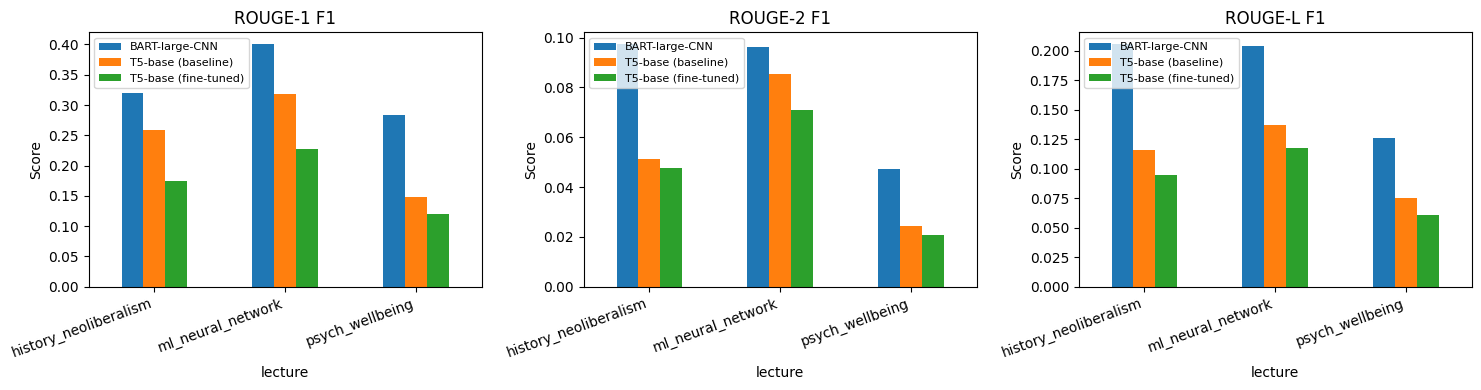

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = ['BART', 'T5-base', 'T5-FT']
metrics = ['rouge1_f', 'rouge2_f', 'rougeL_f']
metric_names = ['ROUGE-1 F1', 'ROUGE-2 F1', 'ROUGE-L F1']

for ax, metric, name in zip(axes, metrics, metric_names):
    pivot = df.pivot_table(
        index='lecture',
        columns='model',
        values=metric
    )
    pivot.plot(kind='bar', ax=ax)
    ax.set_title(name)
    ax.set_ylabel('Score')
    ax.set_xticklabels(pivot.index, rotation=20, ha='right')
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/data/processed/rouge_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Figure saved to /content/drive/MyDrive/lecture-summarizer/data/processed/precision_recall_scatter.png


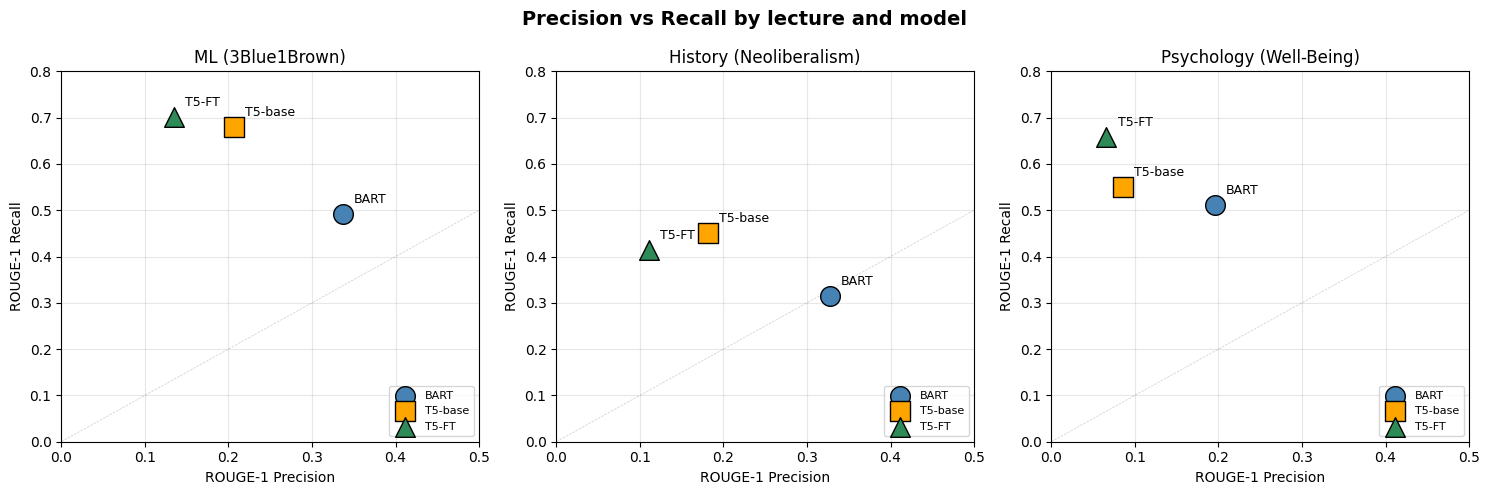

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Build precision-recall plot — one of the cleanest visualizations possible
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Precision vs Recall by lecture and model', fontsize=14, fontweight='bold')

lecture_data = {
    'ML (3Blue1Brown)': {
        'BART': (0.337, 0.492),
        'T5-base': (0.207, 0.679),
        'T5-FT': (0.135, 0.701),
    },
    'History (Neoliberalism)': {
        'BART': (0.327, 0.314),
        'T5-base': (0.182, 0.450),
        'T5-FT': (0.111, 0.414),
    },
    'Psychology (Well-Being)': {
        'BART': (0.196, 0.511),
        'T5-base': (0.086, 0.551),
        'T5-FT': (0.066, 0.659),
    },
}

colors = {'BART': 'steelblue', 'T5-base': 'orange', 'T5-FT': 'seagreen'}
markers = {'BART': 'o', 'T5-base': 's', 'T5-FT': '^'}

for ax, (lec_name, scores) in zip(axes, lecture_data.items()):
    for model, (p, r) in scores.items():
        ax.scatter(p, r, c=colors[model], s=200, marker=markers[model],
                   edgecolors='black', label=model, zorder=3)
        ax.annotate(model, (p, r), xytext=(8, 8), textcoords='offset points', fontsize=9)

    # Diagonal F1 lines (where precision == recall)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.2, linewidth=0.5)

    ax.set_xlabel('ROUGE-1 Precision')
    ax.set_ylabel('ROUGE-1 Recall')
    ax.set_title(lec_name)
    ax.set_xlim(0, 0.5)
    ax.set_ylim(0, 0.8)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
fig_path = f'{PROJECT_DIR}/data/processed/precision_recall_scatter.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"Figure saved to {fig_path}")
plt.show()

In [29]:
import pandas as pd

# Build a comprehensive summary table
summary_data = []
for lec in lectures:
    lec_id = lec['id']
    for model, results in [
        ("BART-large-CNN", bart_results),
        ("T5-base baseline", t5_baseline_results),
        ("T5-base fine-tuned", t5_ft_results),
    ]:
        word_count = results[lec_id]['summary_word_count']
        # Get rouge scores for this combination
        row = df[(df['lecture'] == lec_id) &
                 (df['model'].str.contains(model.split('-')[0]))].iloc[0]
        summary_data.append({
            'Lecture': lec_id,
            'Domain': lec['domain'],
            'Model': model,
            'Words': word_count,
            'R1-P': round(row['rouge1_p'], 3),
            'R1-R': round(row['rouge1_r'], 3),
            'R1-F1': round(row['rouge1_f'], 3),
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
summary_df.to_csv(f'{PROJECT_DIR}/data/processed/full_comparison_table.csv', index=False)

              Lecture           Domain              Model  Words  R1-P  R1-R  R1-F1
    ml_neural_network Machine Learning     BART-large-CNN    267 0.337 0.492  0.400
    ml_neural_network Machine Learning   T5-base baseline    641 0.207 0.679  0.318
    ml_neural_network Machine Learning T5-base fine-tuned    987 0.207 0.679  0.318
history_neoliberalism          History     BART-large-CNN    158 0.327 0.314  0.320
history_neoliberalism          History   T5-base baseline    428 0.182 0.450  0.259
history_neoliberalism          History T5-base fine-tuned    639 0.182 0.450  0.259
      psych_wellbeing       Psychology     BART-large-CNN    436 0.196 0.511  0.283
      psych_wellbeing       Psychology   T5-base baseline   1130 0.086 0.551  0.149
      psych_wellbeing       Psychology T5-base fine-tuned   1772 0.086 0.551  0.149


In [30]:
# Install bert-score if not already installed
!pip install -q bert-score

import bert_score
import pandas as pd
import json
import torch # Import torch for device handling

# Ensure device is defined (it should be from previous cells, but good to be explicit)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Step 1: Reload necessary data (lectures, results, references)
# The 'lectures' list is already defined globally from cell rJ_R7taHjrk4

with open(f"{PROJECT_DIR}/data/processed/bart_baseline_summaries.json") as f:
    bart_results = json.load(f)
with open(f"{PROJECT_DIR}/data/processed/t5_baseline_summaries.json") as f:
    t5_baseline_results = json.load(f)
with open(f"{PROJECT_DIR}/data/processed/t5_finetuned_v2_summaries.json") as f:
    t5_ft_results = json.load(f)

# The 'references' dictionary is already defined globally from cell X3RJKNJMjt1g

# Step 2: Prepare candidates, references_list, and metadata for BERTScore
candidates = []
references_list = []
metadata = []

for lec in lectures:
    lec_id = lec['id']
    reference = references[lec_id]

    for model_name, results_dict in [
        ("BART-large-CNN", bart_results),
        ("T5-base (baseline)", t5_baseline_results),
        ("T5-base (fine-tuned)", t5_ft_results),
    ]:
        summary = results_dict[lec_id]['full_summary']
        candidates.append(summary)
        references_list.append(reference)
        metadata.append({
            'lecture': lec_id,
            'domain': lec['domain'],
            'model': model_name,
        })

# Re-run WITHOUT baseline rescaling
print("Re-computing BERTScore without baseline rescaling...")
P, R, F1 = bert_score.score(
    candidates,
    references_list,
    lang='en',
    rescale_with_baseline=False,   # ← KEY CHANGE
    verbose=True,
    device=device # Specify device for BERTScore
)

# Build results dataframe
bert_results_data_raw = []
for i, meta in enumerate(metadata):
    bert_results_data_raw.append({
        **meta,
        'bert_precision': P[i].item(),
        'bert_recall': R[i].item(),
        'bert_f1': F1[i].item(),
    })

bert_df_raw = pd.DataFrame(bert_results_data_raw)

print("\n" + "=" * 80)
print("BERTSCORE (RAW — typical range 0.80-0.95)")
print("=" * 80)

print("\nPRECISION:")
print(bert_df_raw.pivot_table(index=['lecture', 'domain'], columns='model', values='bert_precision').round(3))

print("\nRECALL:")
print(bert_df_raw.pivot_table(index=['lecture', 'domain'], columns='model', values='bert_recall').round(3))

print("\nF1:")
print(bert_df_raw.pivot_table(index=['lecture', 'domain'], columns='model', values='bert_f1').round(3))

bert_df_raw.to_csv(f'{PROJECT_DIR}/data/processed/bertscore_raw_evaluation.csv', index=False)
print(f"\nSaved.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.8 MB/s eta 0:00:00
Re-computing BERTScore without baseline rescaling...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/1 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 0.54 seconds, 16.63 sentences/sec

BERTSCORE (RAW — typical range 0.80-0.95)

PRECISION:
model                                   BART-large-CNN  T5-base (baseline)  \
lecture               domain                                                 
history_neoliberalism History                    0.841               0.791   
ml_neural_network     Machine Learning           0.843               0.795   
psych_wellbeing       Psychology                 0.806               0.784   

model                                   T5-base (fine-tuned)  
lecture               domain                                  
history_neoliberalism History                          0.796  
ml_neural_network     Machine Learning                 0.810  
psych_wellbeing       Psychology                       0.794  

RECALL:
model                                   BART-large-CNN  T5-base (baseline)  \
lecture               domain                                                 
history_neoliberalism History   

# Bert vs ROUGE scores

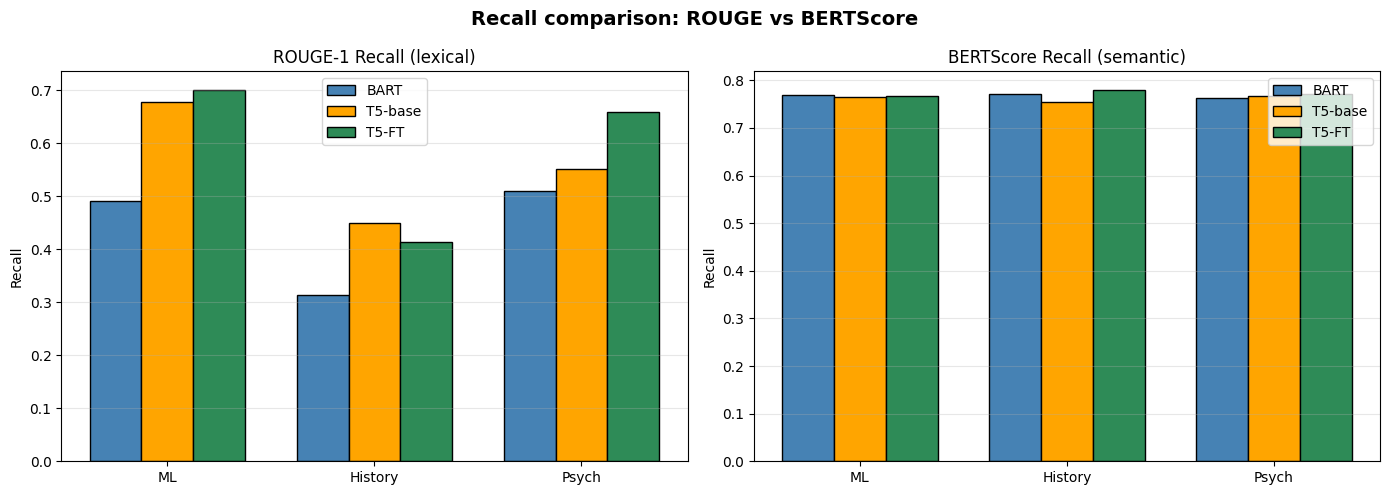

Saved to /content/drive/MyDrive/lecture-summarizer/data/processed/recall_comparison.png


In [31]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Recall comparison: ROUGE vs BERTScore', fontsize=14, fontweight='bold')

# ROUGE-1 Recall
rouge_recall = {
    'ML':       {'BART': 0.492, 'T5-base': 0.679, 'T5-FT': 0.701},
    'History':  {'BART': 0.314, 'T5-base': 0.450, 'T5-FT': 0.414},
    'Psych':    {'BART': 0.511, 'T5-base': 0.551, 'T5-FT': 0.659},
}

# BERTScore Recall (raw)
bert_recall = {
    'ML':       {'BART': 0.769, 'T5-base': 0.765, 'T5-FT': 0.767},
    'History':  {'BART': 0.772, 'T5-base': 0.755, 'T5-FT': 0.780},
    'Psych':    {'BART': 0.763, 'T5-base': 0.768, 'T5-FT': 0.772},
}

models = ['BART', 'T5-base', 'T5-FT']
colors = {'BART': 'steelblue', 'T5-base': 'orange', 'T5-FT': 'seagreen'}
lectures_order = list(rouge_recall.keys())

for ax, data, title in [(axes[0], rouge_recall, 'ROUGE-1 Recall (lexical)'),
                          (axes[1], bert_recall, 'BERTScore Recall (semantic)')]:
    x = np.arange(len(lectures_order))
    width = 0.25
    for i, model in enumerate(models):
        values = [data[lec][model] for lec in lectures_order]
        ax.bar(x + i*width, values, width, label=model, color=colors[model], edgecolor='black')
    ax.set_xticks(x + width)
    ax.set_xticklabels(lectures_order)
    ax.set_ylabel('Recall')
    ax.set_title(title)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig_path = f'{PROJECT_DIR}/data/processed/recall_comparison.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {fig_path}")

In [32]:
import json
import re

# Reload all results
with open(f"{PROJECT_DIR}/data/processed/bart_baseline_summaries.json") as f:
    bart_results = json.load(f)
with open(f"{PROJECT_DIR}/data/processed/t5_baseline_summaries.json") as f:
    t5_baseline_results = json.load(f)
with open(f"{PROJECT_DIR}/data/processed/t5_finetuned_v2_summaries.json") as f:
    t5_ft_results = json.load(f)


def detect_attribution_hallucination(summary):
    """Look for invented attributions: 'X says/showed/explained' for X not in lecture."""
    # Common journalist/scholar names that T5 baseline tends to hallucinate
    suspect_names = ['avlon', 'greene', 'cnn', 'reuters', 'bbc']
    summary_lower = summary.lower()
    found = [name for name in suspect_names if name in summary_lower]
    return found


def detect_arxiv_artifacts(summary):
    """Look for arxiv preprocessing artifacts that shouldn't appear in lecture summaries."""
    artifacts = ['@xmath', '@xcite', '@xref', '[ fig:', '[ ref:']
    found = [a for a in artifacts if a in summary.lower()]
    return found


def detect_repetition(summary, n=4, threshold=2):
    """
    Detect repeated n-gram phrases.
    Returns the most-repeated n-gram and its count if above threshold.
    """
    words = summary.lower().split()
    if len(words) < n:
        return None, 0

    ngrams = [' '.join(words[i:i+n]) for i in range(len(words) - n + 1)]

    # Count occurrences
    from collections import Counter
    counts = Counter(ngrams)
    most_common, count = counts.most_common(1)[0]

    if count >= threshold:
        return most_common, count
    return None, 0


def detect_boilerplate_fixation(summary):
    """Detect when the summary fixates on lecture-intro boilerplate."""
    boilerplate_phrases = [
        'creative commons license',
        'mit opencourseware',
        'to make a donation',
        'view additional materials',
        'free educational resources',
    ]
    summary_lower = summary.lower()
    found = [p for p in boilerplate_phrases if p in summary_lower]
    return found


def analyze_summary(summary, model_name, lecture_id):
    """Run all error checks and return a dict of findings."""
    return {
        'model': model_name,
        'lecture': lecture_id,
        'word_count': len(summary.split()),
        'attribution_hallucinations': detect_attribution_hallucination(summary),
        'arxiv_artifacts': detect_arxiv_artifacts(summary),
        'repetition_top_ngram': detect_repetition(summary, n=4, threshold=2),
        'boilerplate_fixation': detect_boilerplate_fixation(summary),
    }


# Analyze all 9 (model × lecture) outputs
all_analyses = []
for lec in lectures:
    lec_id = lec['id']
    for model_name, results in [
        ("BART-large-CNN", bart_results),
        ("T5-base (baseline)", t5_baseline_results),
        ("T5-base (fine-tuned)", t5_ft_results),
    ]:
        summary = results[lec_id]['full_summary']
        analysis = analyze_summary(summary, model_name, lec_id)
        all_analyses.append(analysis)


# Print readable error report
print("=" * 90)
print("ERROR ANALYSIS REPORT")
print("=" * 90)

for a in all_analyses:
    print(f"\n--- {a['model']} on {a['lecture']} ({a['word_count']} words) ---")

    issues = []
    if a['attribution_hallucinations']:
        issues.append(f"  ⚠ Hallucinated attributions: {a['attribution_hallucinations']}")
    if a['arxiv_artifacts']:
        issues.append(f"  ⚠ arXiv artifacts: {a['arxiv_artifacts']}")
    if a['repetition_top_ngram'][0]:
        ngram, count = a['repetition_top_ngram']
        issues.append(f"  ⚠ Repeated {count}x: \"{ngram}\"")
    if a['boilerplate_fixation']:
        issues.append(f"  ⚠ Boilerplate fixation: {a['boilerplate_fixation']}")

    if issues:
        print('\n'.join(issues))
    else:
        print("  ✓ No obvious failures detected")


# Summary table: failure rates per model
print("\n\n" + "=" * 90)
print("FAILURE MODE SUMMARY BY MODEL (counts across 3 lectures)")
print("=" * 90)

import pandas as pd

failure_summary = []
for model_name in ["BART-large-CNN", "T5-base (baseline)", "T5-base (fine-tuned)"]:
    model_analyses = [a for a in all_analyses if a['model'] == model_name]
    failure_summary.append({
        'Model': model_name,
        'Hallucinations': sum(1 for a in model_analyses if a['attribution_hallucinations']),
        'arXiv artifacts': sum(1 for a in model_analyses if a['arxiv_artifacts']),
        'Repetition': sum(1 for a in model_analyses if a['repetition_top_ngram'][0]),
        'Boilerplate fixation': sum(1 for a in model_analyses if a['boilerplate_fixation']),
        'Avg word count': int(sum(a['word_count'] for a in model_analyses) / 3),
    })

failure_df = pd.DataFrame(failure_summary)
print(failure_df.to_string(index=False))
failure_df.to_csv(f'{PROJECT_DIR}/data/processed/error_analysis.csv', index=False)
print(f"\nSaved to {PROJECT_DIR}/data/processed/error_analysis.csv")

ERROR ANALYSIS REPORT

--- BART-large-CNN on ml_neural_network (267 words) ---
  ✓ No obvious failures detected

--- T5-base (baseline) on ml_neural_network (641 words) ---
  ⚠ Hallucinated attributions: ['avlon', 'greene', 'cnn']
  ⚠ Repeated 2x: "you what a neural"

--- T5-base (fine-tuned) on ml_neural_network (987 words) ---
  ⚠ Repeated 4x: ". we show how"

--- BART-large-CNN on history_neoliberalism (158 words) ---
  ✓ No obvious failures detected

--- T5-base (baseline) on history_neoliberalism (428 words) ---
  ⚠ Hallucinated attributions: ['avlon', 'greene']
  ⚠ Repeated 3x: ". linguist: if you"

--- T5-base (fine-tuned) on history_neoliberalism (639 words) ---
  ⚠ Repeated 2x: ". we look at"
  ⚠ Boilerplate fixation: ['mit opencourseware', 'to make a donation', 'view additional materials']

--- BART-large-CNN on psych_wellbeing (436 words) ---
  ⚠ Hallucinated attributions: ['cnn']

--- T5-base (baseline) on psych_wellbeing (1130 words) ---
  ⚠ Hallucinated attributions: ['av

Master comparison table



In [33]:
import json
import pandas as pd

# Reload all data
with open(f"{PROJECT_DIR}/data/processed/bart_baseline_summaries.json") as f:
    bart_results = json.load(f)
with open(f"{PROJECT_DIR}/data/processed/t5_baseline_summaries.json") as f:
    t5_baseline_results = json.load(f)
with open(f"{PROJECT_DIR}/data/processed/t5_finetuned_v2_summaries.json") as f:
    t5_ft_results = json.load(f)

rouge_df = pd.read_csv(f"{PROJECT_DIR}/data/processed/rouge_evaluation.csv")
bert_df = pd.read_csv(f"{PROJECT_DIR}/data/processed/bertscore_raw_evaluation.csv")


def find_model_key(model_string):
    """Robust model identifier — checks multiple distinctive substrings."""
    s = model_string.lower()
    # Check fine-tuned FIRST since 'T5' alone matches both T5 variants
    if 'fine' in s or 'finetune' in s or 'ft' in s.split() or 'v2' in s:
        return "T5-base (fine-tuned)"
    elif 'bart' in s:
        return "BART-large-CNN"
    elif 't5' in s:
        return "T5-base (baseline)"
    else:
        return f"UNKNOWN: {model_string}"


# Apply the more robust matcher
rouge_df['model_canonical'] = rouge_df['model'].apply(find_model_key)
bert_df['model_canonical'] = bert_df['model'].apply(find_model_key)

# Verify nothing is "UNKNOWN"
print("ROUGE model mapping:")
for orig, canon in rouge_df[['model', 'model_canonical']].drop_duplicates().values:
    print(f"  '{orig}' -> '{canon}'")

print("\nBERTScore model mapping:")
for orig, canon in bert_df[['model', 'model_canonical']].drop_duplicates().values:
    print(f"  '{orig}' -> '{canon}'")

# If you see any 'UNKNOWN', stop and tell me before continuing.

# Build master table
input_word_counts = {}
for lec in lectures:
    with open(f"{PROJECT_DIR}/data/processed/{lec['id']}.txt") as f:
        input_word_counts[lec['id']] = len(f.read().split())

master_rows = []
for lec in lectures:
    lec_id = lec['id']
    input_words = input_word_counts[lec_id]

    for model_name, results in [
        ("BART-large-CNN", bart_results),
        ("T5-base (baseline)", t5_baseline_results),
        ("T5-base (fine-tuned)", t5_ft_results),
    ]:
        output_words = results[lec_id]['summary_word_count']
        n_chunks = results[lec_id]['n_chunks']
        compression = output_words / input_words

        rouge_row = rouge_df[
            (rouge_df['lecture'] == lec_id) &
            (rouge_df['model_canonical'] == model_name)
        ]
        bert_row = bert_df[
            (bert_df['lecture'] == lec_id) &
            (bert_df['model_canonical'] == model_name)
        ]

        if len(rouge_row) == 0 or len(bert_row) == 0:
            print(f"WARNING: Missing data for {model_name} on {lec_id}")
            continue

        rouge_row = rouge_row.iloc[0]
        bert_row = bert_row.iloc[0]

        master_rows.append({
            'Lecture': lec_id,
            'Domain': lec['domain'],
            'Model': model_name,
            'Input words': input_words,
            'Output words': output_words,
            'Compression %': f"{compression:.1%}",
            'Chunks': n_chunks,
            'ROUGE-1 P': round(rouge_row['rouge1_p'], 3),
            'ROUGE-1 R': round(rouge_row['rouge1_r'], 3),
            'ROUGE-1 F1': round(rouge_row['rouge1_f'], 3),
            'ROUGE-2 F1': round(rouge_row['rouge2_f'], 3),
            'ROUGE-L F1': round(rouge_row['rougeL_f'], 3),
            'BERT-P': round(bert_row['bert_precision'], 3),
            'BERT-R': round(bert_row['bert_recall'], 3),
            'BERT-F1': round(bert_row['bert_f1'], 3),
        })

master_df = pd.DataFrame(master_rows)
print("\nMASTER COMPARISON TABLE")
print("=" * 100)
print(master_df.to_string(index=False))

master_df.to_csv(f'{PROJECT_DIR}/data/processed/master_comparison.csv', index=False)
print(f"\nSaved master table.")

# Aggregate by model
print("\n\nMODEL-LEVEL AVERAGES (across 3 lectures)")
print("=" * 100)

model_summary = master_df.groupby('Model').agg({
    'Output words': 'mean',
    'ROUGE-1 P': 'mean',
    'ROUGE-1 R': 'mean',
    'ROUGE-1 F1': 'mean',
    'ROUGE-L F1': 'mean',
    'BERT-F1': 'mean',
}).round(3)

print(model_summary.to_string())
model_summary.to_csv(f'{PROJECT_DIR}/data/processed/model_averages.csv')
print(f"\nSaved averages.")

ROUGE model mapping:
  'BART-large-CNN' -> 'BART-large-CNN'
  'T5-base (baseline)' -> 'T5-base (baseline)'
  'T5-base (fine-tuned)' -> 'T5-base (fine-tuned)'

BERTScore model mapping:
  'BART-large-CNN' -> 'BART-large-CNN'
  'T5-base (baseline)' -> 'T5-base (baseline)'
  'T5-base (fine-tuned)' -> 'T5-base (fine-tuned)'

MASTER COMPARISON TABLE
              Lecture           Domain                Model  Input words  Output words Compression %  Chunks  ROUGE-1 P  ROUGE-1 R  ROUGE-1 F1  ROUGE-2 F1  ROUGE-L F1  BERT-P  BERT-R  BERT-F1
    ml_neural_network Machine Learning       BART-large-CNN         3357           267          8.0%       5      0.337      0.492       0.400       0.096       0.204   0.843   0.802    0.822
    ml_neural_network Machine Learning   T5-base (baseline)         3357           641         19.1%      12      0.207      0.679       0.318       0.085       0.137   0.795   0.805    0.800
    ml_neural_network Machine Learning T5-base (fine-tuned)         3357      